#Introduction

In this comprehensive notebook, we’ll explore the development of a Multimodal Retrieval-Augmented Generation (RAG) system from scratch, without relying on any prebuilt frameworks. Our goal is to build a robust system capable of handling both text and images extracted from PDFs. This represents a significant advancement over traditional RAG approaches that primarily focus on unstructured text data. By incorporating multiple modalities—text and visual content—we can create a system that understands and retrieves information in a more holistic and contextually rich manner.

Multimodal RAG is a cutting-edge framework that combines the strengths of text processing with image understanding, making it particularly suitable for tasks involving multimedia content. By integrating text data with visual elements such as charts, images, and infographics, this approach ensures a deeper comprehension of information, enabling the system to generate more accurate and contextually rich responses.

#Goal of This Notebook

In this notebook, we will build a Multimodal RAG system entirely from scratch, which can efficiently process and retrieve information from a PDF-based dataset containing both textual and visual content. The key steps include:

Extracting Text and Images: Manually parse PDFs to extract text chunks and images for downstream processing.

Generating Vector Representations:




1.   Use pretrained model for text embeddings (nomic-embed).
2.   Use vision model (nomic-vision) to generate vector embeddings for images.



Creating Multimodal Indexes: Combine text and image embeddings into separate vector indexes for efficient multimodal similarity search.

Retrieving and Generating Responses:
Perform a multimodal similarity search to retrieve relevant text and images based on a user query.

Use a multimodal language model to generate a response by combining the retrieved text and images.

| Feature                     | Traditional RAG                           | Multimodal RAG                                |
|-----------------------------|-------------------------------------------|-----------------------------------------------|
| **Input Data**              | Text-only documents                      | Text and images extracted from PDFs           |
| **Knowledge Representation**| Text embeddings and vector indexes       | Combined embeddings for text and image data   |
| **Search Capability**       | Textual vector similarity search         | Multimodal vector similarity search (text + images) |
| **Use Case**                | Unstructured text data                   | Rich multimedia data (e.g., reports, manuals) |
| **Generation**              | Context-aware textual responses          | Context-aware multimodal responses leveraging text and visual cues |


#MultiModal RAG

[image source](https://medium.com/llamaindex-blog/multimodal-rag-pipeline-with-llamaindex-and-neo4j-a2c542eb0206)






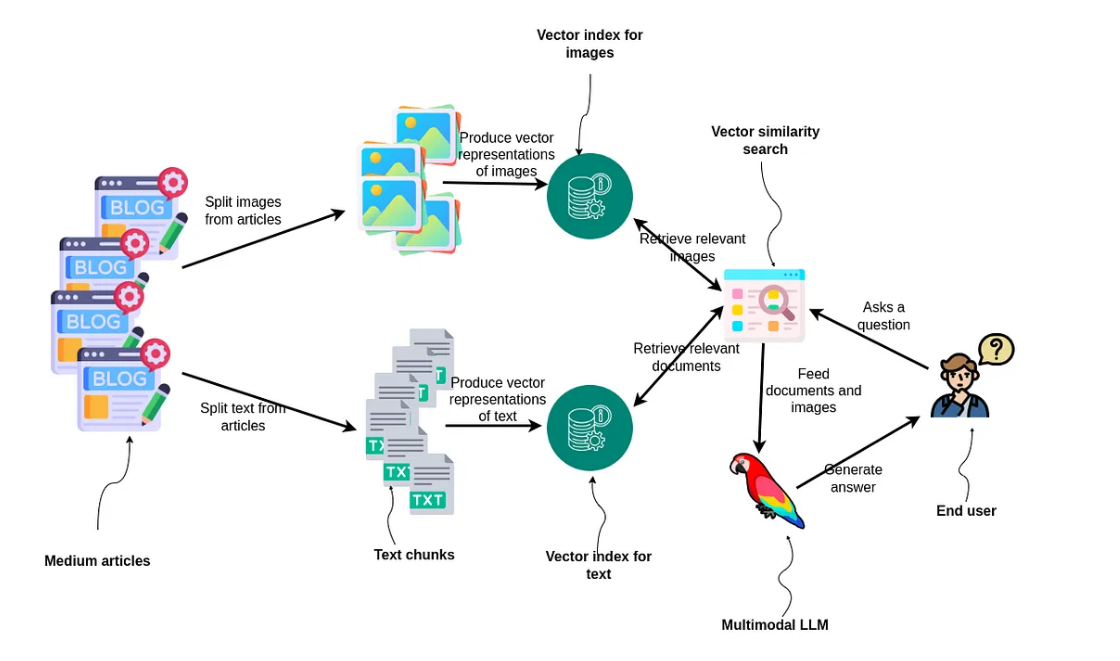

#Why Build From Scratch?

By not relying on prebuilt frameworks, this notebook allows you to:

Gain a deep understanding of the core principles and mechanics behind Multimodal RAG systems.

Customize each step, from parsing and embedding generation to retrieval and generation.

Build a system that can be fine-tuned for your specific use case, offering flexibility and control.

#Install Libraries

In [ ]:
#install dependencies
%%capture
!pip install openai==1.55.3 httpx==0.27.2 --force-reinstall --quiet

In [ ]:
!pip install qdrant_client
!pip install transformers
!pip install transformers torch pillow
!pip install --upgrade nltk
!pip install sentence-transformers
!pip install --upgrade qdrant-client fastembed Pillow

  Using cached pillow-11.1.0-cp310-cp310-manylinux_2_28_x86_64.whl.metadata (9.1 kB)


#Initializing openai client:

initialize your client with your endpoints or api key



In [ ]:

from openai import ChatCompletion
import openai
import os
from openai import AzureOpenAI
AZURE_OPENAI_ENDPOINT = "your endpoints"
AZURE_OPENAI_KEY = "your key"

openaiclient =AzureOpenAI(
  azure_endpoint =AZURE_OPENAI_ENDPOINT,
  api_key=AZURE_OPENAI_KEY,
  api_version="api version",

)

# Content (Images and Text) extraction from pdf


Extracting Text and images from pdf using PyMuPDF:

The code below extracts images and save them in a output directory


In [ ]:
!pip install PyMuPDF

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 39.8 MB/s eta 0:00:00


Extracting Images

In [ ]:
#images
import fitz  # PyMuPDF
import os
import time
def extract_images_from_pdf(pdf_path, output_folder):

    pdf_document = fitz.open(pdf_path)


    os.makedirs(output_folder, exist_ok=True)
    for page_number in range(len(pdf_document)):
        page = pdf_document[page_number]

        images = page.get_images(full=True)

        for image_index, img in enumerate(images):
            xref = img[0]

            base_image = pdf_document.extract_image(xref)
            image_bytes = base_image["image"]
            image_ext = base_image["ext"]


            image_filename = f"page_{page_number+1}_image_{image_index+1}.{image_ext}"
            image_path = os.path.join(output_folder, image_filename)

            with open(image_path, "wb") as image_file:
                image_file.write(image_bytes)

            print(f"Saved: {image_path}")


    pdf_document.close()

Extracting text

In [ ]:
#text
import fitz  # PyMuPDF library

def read_text_pymupdf(path):
    """Extracts text from a PDF using PyMuPDF."""
    doc = fitz.open(path)
    text_results = []
    for page in doc:
        text = page.get_text()
        text_results.append(text)
    return text_results


In [ ]:
def get_contents(pdf_path, output_directory):
  """Extracts text and images from a PDF, saves images, and returns text and elapsed time."""

  start_time = time.time()
  extract_images_from_pdf(pdf_path, output_directory)
  text_results=read_text_pymupdf(pdf_path)
  end_time = time.time()
  print(f"Time taken to extract text and images: {end_time - start_time} seconds")
  return(text_results,end_time)


In [ ]:
import os
pdf_path = "path/to/your/file"
output_directory = "/content/IF10244"
text_results,total_read_time=get_contents(pdf_path, output_directory)


Saved: /content/IF10244/page_1_image_1.png
Saved: /content/IF10244/page_1_image_2.png
Saved: /content/IF10244/page_1_image_3.png
Saved: /content/IF10244/page_2_image_1.png
Saved: /content/IF10244/page_2_image_2.png
Time taken to extract text and images: 0.14003658294677734 seconds


In [ ]:
text_results[0][:150]

' \nhttps://crsreports.congress.gov \nUpdated June 1, 2023\nWildfire Statistics\nWildfires are unplanned fires, including lightning-caused \nfires, unauthor'

In [ ]:
len(text_results)

3

#PreProcessing Text

I have implemented recursive chunking, a process that breaks down large content into smaller, manageable pieces.This ensures efficient processing, especially for large text documents.



In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=2048,
        chunk_overlap=50,
        length_function=len,
        is_separator_regex=False,
        separators=[
            "\n\n",
            "\n",
            " ",
            ".",
            ",",
            "\u200b",  # Zero-width space
            "\uff0c",  # Fullwidth comma
            "\u3001",  # Ideographic comma
            "\uff0e",  # Fullwidth full stop
            "\u3002",  # Ideographic full stop
            "",
        ],
    )

doc_texts = text_splitter.create_documents(text_results)



Adding metadata to text chunks

In [ ]:
import uuid
for i in range(len(doc_texts)):
  unique_id = str(uuid.uuid4())
  doc_texts[i].metadata['document_info'] = pdf_path
  doc_texts[i].metadata['uuid'] = unique_id

  print(doc_texts[0].metadata)


{'document_info': '/content/drive/MyDrive/pdfs for multi modal RAG/IF10244.pdf', 'uuid': '26b6c3f7-edbe-4d48-8da2-f18839f96779'}
{'document_info': '/content/drive/MyDrive/pdfs for multi modal RAG/IF10244.pdf', 'uuid': '26b6c3f7-edbe-4d48-8da2-f18839f96779'}
{'document_info': '/content/drive/MyDrive/pdfs for multi modal RAG/IF10244.pdf', 'uuid': '26b6c3f7-edbe-4d48-8da2-f18839f96779'}
{'document_info': '/content/drive/MyDrive/pdfs for multi modal RAG/IF10244.pdf', 'uuid': '26b6c3f7-edbe-4d48-8da2-f18839f96779'}
{'document_info': '/content/drive/MyDrive/pdfs for multi modal RAG/IF10244.pdf', 'uuid': '26b6c3f7-edbe-4d48-8da2-f18839f96779'}
{'document_info': '/content/drive/MyDrive/pdfs for multi modal RAG/IF10244.pdf', 'uuid': '26b6c3f7-edbe-4d48-8da2-f18839f96779'}


In [ ]:
doc_texts[0]

Document(metadata={'document_info': '/content/drive/MyDrive/pdfs for multi modal RAG/IF10244.pdf', 'uuid': '26b6c3f7-edbe-4d48-8da2-f18839f96779'}, page_content='https://crsreports.congress.gov \nUpdated June 1, 2023\nWildfire Statistics\nWildfires are unplanned fires, including lightning-caused \nfires, unauthorized human-caused fires, and escaped fires \nfrom prescribed burn projects. States are responsible for \nresponding to wildfires that begin on nonfederal (state, \nlocal, and private) lands, except for lands protected by \nfederal agencies under cooperative agreements. The federal \ngovernment is responsible for responding to wildfires that \nbegin on federal lands. The Forest Service (FS)—within the \nU.S. Department of Agriculture—carries out wildfire \nmanagement and response across the 193 million acres of \nthe National Forest System (NFS). The Department of the \nInterior (DOI) manages wildfire response for more than 400 \nmillion acres of national parks, wildlife refuges

#Loading embedding models

For now, we load embedding models for both text and images and test them out. Then, we will use these embedding models to generate embeddings for our text and images, which will be stored in the Qdrant vector database.



Loading text embedding model

In [ ]:
from transformers import AutoTokenizer, AutoModel

# Load the tokenizer and model
text_tokenizer = AutoTokenizer.from_pretrained("nomic-ai/nomic-embed-text-v1.5", trust_remote_code=True)
text_model = AutoModel.from_pretrained("nomic-ai/nomic-embed-text-v1.5", trust_remote_code=True)

def get_text_embeddings(text):
    inputs = text_tokenizer(text, return_tensors="pt", padding=True, truncation=True)
    outputs = text_model(**inputs)
    embeddings = outputs.last_hidden_state.mean(dim=1)
    return embeddings[0].detach().numpy()

# Example usage
text = "This is a test sentence."
embeddings = get_text_embeddings(text)
print(embeddings[:5])


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

...

A new version of the following files was downloaded from https://huggingface.co/nomic-ai/nomic-bert-2048:
- configuration_hf_nomic_bert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_hf_nomic_bert.py:   0%|          | 0.00/95.4k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/nomic-ai/nomic-bert-2048:
- modeling_hf_nomic_bert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/547M [00:00<?, ?B/s]

[ 1.2799692   0.40158355 -3.5162656  -0.3981321   1.5919138 ]


In [ ]:
text_embeddings_size=len(embeddings)
text_embeddings_size

768

Loading image embedding model and testing it

In [ ]:
from transformers import AutoModel, AutoProcessor
from PIL import Image
import torch
model = AutoModel.from_pretrained("nomic-ai/nomic-embed-vision-v1.5", trust_remote_code=True)
processor = AutoProcessor.from_pretrained("nomic-ai/nomic-embed-vision-v1.5")
# Load the image
image = Image.open("path/to/your/image")
inputs = processor(images=image, return_tensors="pt")

model.eval()


with torch.no_grad():
    outputs = model(**inputs)

embeddings = outputs.last_hidden_state
print(embeddings)


config.json:   0%|          | 0.00/2.14k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/372M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/791 [00:00<?, ?B/s]

The repository for nomic-ai/nomic-embed-vision-v1.5 contains custom code which must be executed to correctly load the model. You can inspect the repository content at https://hf.co/nomic-ai/nomic-embed-vision-v1.5.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y
The repository for nomic-ai/nomic-embed-vision-v1.5 contains custom code which must be executed to correctly load the model. You can inspect the repository content at https://hf.co/nomic-ai/nomic-embed-vision-v1.5.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y
tensor([[[ -65.9836, -159.3906,  -66.7718,  ..., -166.6718,   43.6248,
           105.7980],
         [-108.8404, -180.7122, -151.0838,  ..., -187.9923,  123.3978,
           156.5277],
         [ -78.1504, -158.7229, -123.2848,  ..., -132.8579,  121.9809,
           159.3696],
         ...,
         [  -0.

Generating Text Embedding

In [ ]:
#TEXT EMBEDDING
texts_embeded = [get_text_embeddings(document.page_content) for document in doc_texts]


In [ ]:
text_embeddings_size=len(texts_embeded[0])
text_embeddings_size


768

Generating Image Embedding

In [ ]:
#IMAGE EMBEDDINGS

In [ ]:
output_directory

'/content/IF10244'

In [ ]:
import os
from PIL import Image
import torch
import numpy as np
image_embeddings = []


image_files = os.listdir(output_directory)

for img in image_files:
    try:
        image = Image.open(os.path.join(output_directory, img))


        inputs = processor(images=image, return_tensors="pt")


        model.eval()

        with torch.no_grad():
            outputs = model(**inputs)


        embeddings = outputs.last_hidden_state
        print(f"Image: {img}, Embedding shape: {embeddings.shape}")


        if embeddings.size(0) > 0:  # Ensure the batch size is non-zero

            image_embedding = embeddings.mean(dim=1).squeeze().cpu().numpy()
            image_embeddings.append(image_embedding)
        else:
            print(f"Skipping image {img} due to empty embeddings.")

    except Exception as e:
        print(f"Error processing {img}: {e}")


Image: page_1_image_2.png, Embedding shape: torch.Size([1, 197, 768])
Image: page_1_image_3.png, Embedding shape: torch.Size([1, 197, 768])
Image: page_2_image_2.png, Embedding shape: torch.Size([1, 197, 768])
Image: page_2_image_1.png, Embedding shape: torch.Size([1, 197, 768])
Image: page_1_image_1.png, Embedding shape: torch.Size([1, 197, 768])


In [ ]:
len(image_embeddings)

5

In [ ]:
text_embeddings_size

768

In [ ]:
len(image_embeddings[0])

768

In [ ]:
image_embeddings_size=len(image_embeddings[0])
image_embeddings_size

768

#Initializing Qdrant-Client

We create separate collections for both image and text embeddings in Qdrant to run queries independently on each. Then, we store our embeddings in both collections one by one.

In [ ]:
from qdrant_client import QdrantClient, models

client = QdrantClient(":memory:") #if you're using Google Collab, this option is suitable only for simple prototypes/demos with Python client

creating separate collections

In [ ]:
if not client.collection_exists("text"): #creating a Collection
 client.create_collection(
        collection_name ="text",
      vectors_config=models.VectorParams(
        size=text_embeddings_size,  # Vector size is defined by used model
        distance=models.Distance.COSINE,
    ),
 )



In [ ]:
# Check if the collection exists, and create it if not
if not client.collection_exists("images"):
    client.create_collection(
        collection_name="images",
        vectors_config=models.VectorParams(
        size=image_embeddings_size,  # Vector size is defined by used model
        distance=models.Distance.COSINE,
    ),
  )


STORING EMBEDDINGS INTO COLLECTIONS

In [ ]:
#storing embedding of Text in the 'text' collection

client.upload_points(
    collection_name="text",
    points=[
        models.PointStruct(
            id=doc.metadata['uuid'],
            vector=np.array(texts_embeded[idx]),
            payload={
                "metadata": doc.metadata,
                "content": doc.page_content
            }
        )
        for idx, doc in enumerate(doc_texts)
    ]
)


In [ ]:
len(texts_embeded)

6

In [ ]:
#storing embedding of Text in the 'text' collection

import uuid


# Ensure that image_embeddings are not empty
if len(image_embeddings) > 0:
    # Upload points to Qdrant
    client.upload_points(
        collection_name="images",
        points=[
            models.PointStruct(
                id=str(uuid.uuid4()),  # unique id of a point,
                vector= np.array(image_embeddings[idx])  ,
                payload={"image_path": output_directory+'/'+str(image_files[idx])}  # Image path as metadata
            )
            for idx in range(len(image_files))  # Iterate over indices of the image list
        ]
    )
else:
    print("No valid embeddings found, nothing to upload.")


#MULTIMODAL RETRIEVER

Now, we combine everything to create a multimodal retriever and displayer that retrieves the top 3 vectors for both text and images separately from each collection. This allows the system to independently fetch the most relevant text chunks and image embeddings based on the query. You can adjust the number of top results retrieved (e.g., increase or reduce the number of vectors) based on your requirements. The multimodal retriever ensures that the most contextually relevant chunks are retrieved from both modalities, which can then be fed into a multimodal language model (MLLM) for further processing and response generation.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
query=get_text_embeddings("What does the acres burned  graph tells us?")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def MultiModalRetriever(user_query):
    """
    Retrieve multimodal results (text and images).

    Parameters:
    - user_query: The user's query string.
    """
    query = get_text_embeddings(user_query)

    # Retrieve text hits
    text_hits = client.query_points(
        collection_name="text",
        query=query,
        limit=3,
    ).points
    # Retrieve image hits
    Image_hits = client.query_points(
        collection_name="images",
        query=query,
        limit=3,
    ).points

    return text_hits, Image_hits


MultiModal Retriever Display





In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def MultiModalRetrieverDisplay(text_hits,Image_hits, text_trunc_length=150):

    """
    Displays text and image results from a multimodal retriever.

    Parameters:
    ----------
    text_hits : list
        List of text results with `id`, `payload`, and `score`.
    Image_hits : list
        List of image results with `id`, `payload`, and `score`.
    text_trunc_length : int, optional
        Maximum length for displayed text content (default is 150).

    Displays:
    --------
    - Text results in bold with IDs, truncated content, and scores.
    - Image results in a matplotlib plot with scores in titles.
    """

    print("\033[1mText Results:\033[0m")
    for i, hit in enumerate(text_hits, 1):
        print("NODEID:",hit.id)
        content = hit.payload['content']
        truncated_content = content[:text_trunc_length] + "..." if len(content) > text_trunc_length else content

        bold_truncated_content = f"\033[1m{truncated_content}"
        print(f"{i}. {bold_truncated_content} | Score: {hit.score}")


    print("\nImage Results:")


    fig, axes = plt.subplots(1, len(Image_hits), figsize=(15, 5))  # Adjust figsize as needed
    for ax, hit in zip(axes, Image_hits):
        image_path = hit.payload['image_path']
        print(f"Displaying image: {image_path} | Score: {hit.score}")

        img = mpimg.imread(image_path)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"Score: {hit.score}", fontsize=10)


    plt.suptitle("Image Results", fontsize=16)
    plt.tight_layout()
    plt.show()


Text Results:
NODEID: 77d05549-e217-46c7-ac61-01c40931d738
1. Wildfire Statistics 
https://crsreports.congress.gov 
In 2022, 52% of the nationwide acreage burned by wildfires 
was on federal lands (4.0 million ac... | Score: 0.7699108938375298
NODEID: 953eac11-3cae-4516-83f3-e8238a068e98
2. <0.1 
<0.1 
<0.1 
<0.1 
Nonfederal 
4.1 
1.6 
3.1 
1.9 
3.6 
Total 
8.8 
4.7 
10.1 
7.1 
7.6 
Source: National Interagency Coordination Center (NICC) ... | Score: 0.700512792875664
NODEID: 68825665-8126-427c-85ae-bf34a6b92c94
3. extent to which nationwide resources—including personnel 
and equipment—are engaged in wildfire suppression. A 
proxy for resource commitments is the ... | Score: 0.6926368524681149

Image Results:
Displaying image: /content/IF10244/page_1_image_2.png | Score: 0.07423844180679465
Displaying image: /content/IF10244/page_2_image_2.png | Score: 0.05348237492817942
Displaying image: /content/IF10244/page_1_image_3.png | Score: 0.04117556647542421


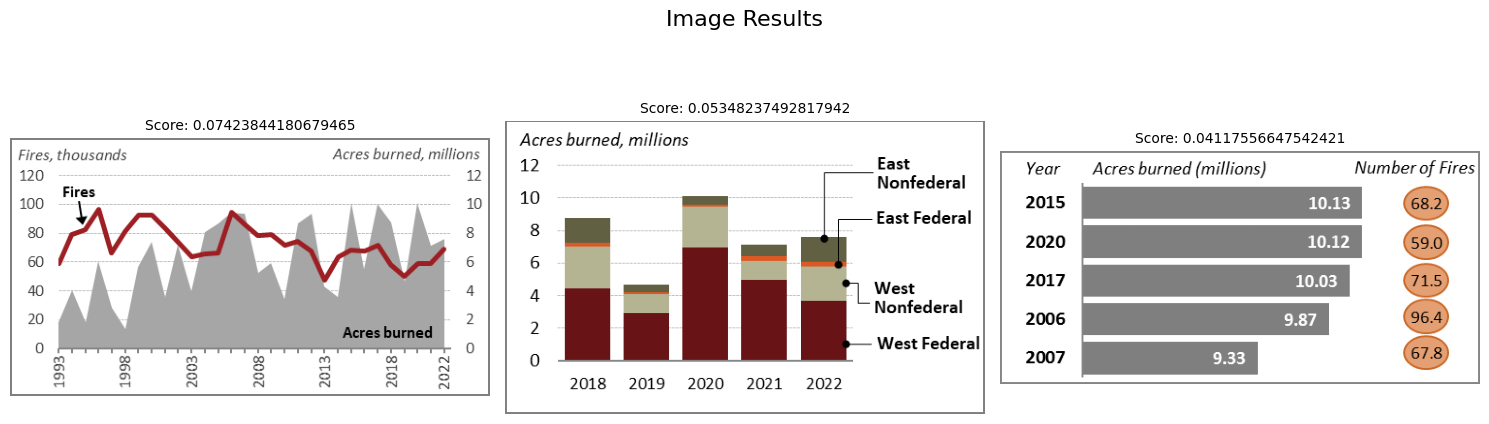

In [ ]:
text_hits, Image_hits=MultiModalRetriever("how much of acre burned in 2022?")
MultiModalRetrieverDisplay(text_hits,Image_hits, text_trunc_length=150)

In [ ]:

retrieved_images=[i.payload['image_path'] for i in Image_hits]



In [ ]:
retrieved_images

['/content/IF10244/page_1_image_2.png',
 '/content/IF10244/page_2_image_2.png',
 '/content/IF10244/page_1_image_3.png']

#Multimodal LLM Integration

For multimodal integration, we take the retrieved results from the multimodal retriever, along with the user's query, and feed them into a multimodal LLM. The function accepts the user's query and text as context, and images as file paths. The image paths are converted into Base64 encoding for seamless processing. The user's query, textual context, and Base64-encoded images are iteratively passed through the multimodal LLM. By processing both the textual and visual data along with the user's query, the multimodal LLM generates a contextually relevant and comprehensive answer that effectively integrates information from all modalities.

In [ ]:
from openai import ChatCompletion
import openai
import base64
from base64 import b64decode
import os
def MultiModalRAG(
    context: list,
    images: list,
    user_query: str,
    client: client,
    model: str = "gpt-4o-large"):  # The name of multimodal LLM you are using
    generation_prompt = f"""
    Based on the given context,must answer the user query,
    context can be tables, texts or Images. Provide the answer from contexts.
    user query: {user_query}

    Contexts: {context}\n
    Output:
    """

    # Helper function to encode an image as a base64 string
    def encode_image(image_path):
        if image_path:
            with open(image_path, "rb") as image_file:
                return base64.b64encode(image_file.read()).decode()
        return None


    image_paths = images
    messages = [
        {
            "role": "system",
            "content": "You are a helpful assistant."
        },
        {
            "role": "user",
            "content": generation_prompt,
        }
    ]

    # Encode images and add them to the messages if present
    for image_path in image_paths:
        img_base64 = encode_image(image_path)
        if img_base64:
            # Adding the image base64 string as part of the text content
            messages.append({
                "role": "user",
                "content": [
                  {
                      "type": "image_url",
                      "image_url": {
                          "url": f"data:image/jpeg;base64,{img_base64}"  # Send the base64-encoded image
                      },
                  },
              ],
            })

    # Create the chat completion
    chat_completion = client.chat.completions.create(
        messages=messages,
        model=model,
        temperature=0.5,
        top_p=0.99,
    )

    return chat_completion.choices[0].message.content


In [ ]:
#combines multimodal llm and retriever

In [ ]:
def RAG(query):
  text_hits, Image_hits=MultiModalRetriever(query)

  retrieved_images=[i.payload['image_path'] for i in Image_hits]
  answer=MultiModalRAG(text_hits,retrieved_images,query,openaiclient)
  return(answer)

In [ ]:
RAG("how much of acre burned in 2019?")

'In 2019, approximately 4.7 million acres were burned by wildfires.'